In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [6]:
df = pd.read_csv('heart.csv')
print("Dataset shape", df.shape)
print("\nData info", df.info())
print("\nTarget distributuion\n", df['target'].value_counts())

Dataset shape (1025, 14)
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Data info None

Target distributuion
 target
1    526
0    499
Name: count, dtype: int64


In [7]:
numerical_columns=['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_columns=['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

X=df.drop(columns=['target'])
y=df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Processed numerical columns
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

#Processed categorical columns
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

#Both at the same time
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_columns),
        ('cat', categorical_transformer, categorical_columns)
    ]
)

print("\nPreprocessing pipeline created successfully.")


Preprocessing pipeline created successfully.


In [9]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    clf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('feature_selection', SelectKBest(score_func=f_classif, k=10)),
        ('classifier', model)
    ])
    clf_pipeline.fit(X_train, y_train)
    y_pred = clf_pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Pipeline': clf_pipeline
    }

In [10]:
df_results = pd.DataFrame(results).T.iloc[:, :4]
df_results = df_results.sort_values(by='F1 Score', ascending=False)
print("\nModel performance comparison:\n", df_results)


Model performance comparison:
                         Accuracy Precision    Recall  F1 Score
Random Forest           0.985366       1.0  0.971429  0.985507
K-Nearest Neighbors     0.912195  0.948454   0.87619  0.910891
Support Vector Machine  0.907317   0.90566  0.914286  0.909953
Logistic Regression     0.858537  0.833333  0.904762   0.86758


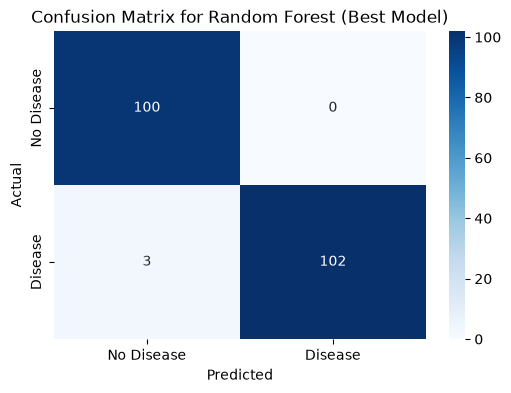

DETAILED TEXT REPORT
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       100
           1       1.00      0.97      0.99       105

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [11]:
best_model_name = df_results.index[0]
best_model_pipeline = results[best_model_name]['Pipeline']

y_pred_best = best_model_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix for {best_model_name} (Best Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


print("DETAILED TEXT REPORT")
print(classification_report(y_test, y_pred_best))

In [12]:
import joblib
joblib.dump(best_model_pipeline, 'best_heart_disease_model.pkl')
print("Model saved as 'best_heart_disease_model.pkl' successfully.")

Model saved as 'best_heart_disease_model.pkl' successfully.
